


# Interpolación de Lagrange

Usando el modulo scipy podemos el polinomio $P(x)$ que interpola los n-datos $(x_i,y_i)$ usando el metodo de Lagrange.  Recordar que el polinomio interpolante de Lagrange se define como

$$P(x) = \sum^{n}_{i=0} y_i L_i(x)$$

En donde los $L_i(x)$ son los polinomios de Lagrange definidos como:

$$L_i(x) = \prod^{n}_{j=0 (i \neq j)} \dfrac{x-x_j}{x_i-x_j}$$

Donde

- $L_i(x_j) = 0$

- $L_i(x_i) = 1$

Ejemplo:



**Ejemplo**

Dado que los puntos son $(-1, 1), (0, 0)$ y $(1, 1)$, los polinomios de Lagrange son:


<br>

- Para el punto $(-1, 1)$:
\begin{equation}
L_1(x) = \dfrac{(x-0)(x-1)}{( (-1) - 0 )( (-1) - 1  )} =\frac{x(x - 1)}{2}
\end{equation}

- Para el punto $(0, 0)$:
\begin{equation}
L_2(x) = \dfrac{(x- (-1) )(x - 1)}{( (0) - (-1) )( (0) - 1  )} = -(x^2 - 1)
\end{equation}

- Para el punto $(1, 1)$:
\begin{equation}
L_3(x) = \dfrac{(x-(-1) )(x - 0)}{( (1) - (-1) )( (1) - 0  )} = \frac{(x + 1)x}{2}
\end{equation}

<br>

El polinomio de Lagrange que pasa por estos puntos es la suma de estos términos ponderados por las coordenadas $y$ de los puntos correspondientes:

\begin{equation}
P(x) = 1 \cdot L_1(x) + 0 \cdot L_2(x) + 1 \cdot L_3(x)
\end{equation}

<br>

Simplificando esta expresión, obtenemos:
\begin{equation}
P(x) = \frac{x^2 - x}{2} + \frac{x^2 + x}{2}
\end{equation}

 <br>

\begin{equation}
\boxed{ P(x) =  x^2 }
\end{equation}




## ¿Como programar el polinomio de Lagrange?

###**programando paso a paso**

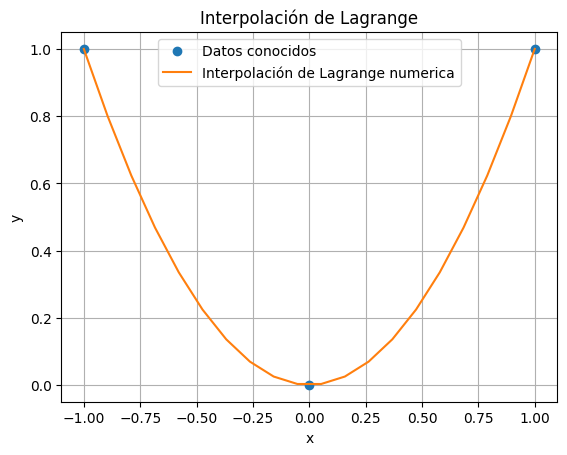

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def lagrange_interpolacion(x, y, x_interp):
    """
    Realiza la interpolación de Lagrange.

    Args:
        x (array): Coordenadas x de los puntos conocidos.
        y (array): Coordenadas y de los puntos conocidos.
        x_interp (array): Coordenadas x en las que se desea interpolar.

    Returns:
        array: Coordenadas y interpoladas correspondientes a x_interp.
    """
    n = len(x)
    result = np.zeros_like(x_interp)

    for i in range(n):
        numerator = 1
        denominator = 1

        for j in range(n):

            if j != i:
                numerator   *= (x_interp - x[j])
                denominator *= (x[i]     - x[j])

        result += y[i] * numerator / denominator

    return result



#======================================
# Puntos de ejemplo
x = np.array([-1,0, 1])
y = np.array([1,0,1])
#======================================



# Coordenadas x en las que se desea interpolar
x_interp = np.linspace(-1,1, 20)


# Interpolación numérica
y_interp_lagrange_numerica = lagrange_interpolation(x, y, x_interp)



# Visualización de los resultados
plt.plot(x, y, 'o', label='Datos conocidos')



plt.plot(x_interp, y_interp_lagrange_numerica, label='Interpolación de Lagrange numerica' )

plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolación de Lagrange')
plt.legend()
plt.grid(True)
plt.show()

Comparacion con la solucion exacta

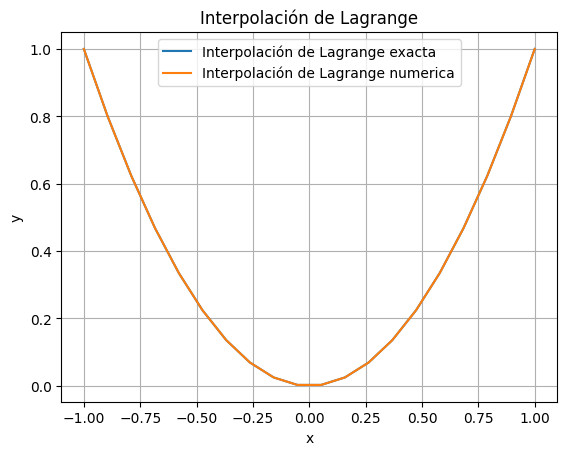

In [ ]:

# Solucion teorica
y_interp_lagrange_exacta = x_interp **2


plt.plot(x_interp, y_interp_lagrange_exacta, label='Interpolación de Lagrange exacta' )

plt.plot(x_interp, y_interp_lagrange_numerica, label='Interpolación de Lagrange numerica' )
plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolación de Lagrange')
plt.legend()
plt.grid(True)
plt.show()

### **usando scipy**

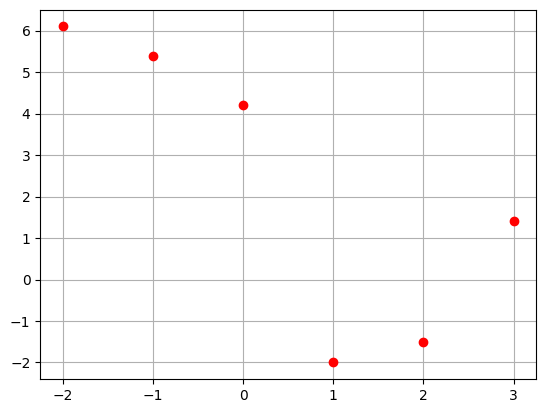

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Nuevo comando!
from scipy.interpolate import lagrange



#x = np.linspace(-2,2, 8)
#y = -x**2

x = np.array([-2,-1,0,1,2,3])
y = np.array([6.1, 5.4, 4.2, -2, -1.5,1.4])


#grafico de los puntos
plt.plot( x , y , 'ro' , label='puntos')
plt.grid()




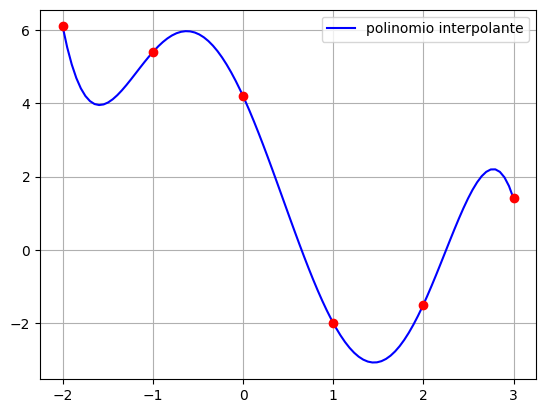

In [ ]:
#=================================================
#polinomio de lagrange( es una funcion de scipy )!!!
PolinomioDeLagrange = lagrange(x, y)
#=================================================


#dominio entre -1 y 1 para evaluar el polinomio
dominiox = np.linspace(-2,3, 100)
plt.plot( dominiox , PolinomioDeLagrange(dominiox) , 'b' , label='polinomio interpolante')

plt.plot(x,y,"or")
#adicionando cosas al grafico
plt.legend()
plt.grid()


#mostrando el grafico
plt.show()